<a href="https://colab.research.google.com/github/zeosapka/glass-box-ai-research/blob/main/notebooks/09_graded_transformer_intervention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
# ============================================================
# E08 — Kademeli Müdahale (Graded Intervention)
# Amaç: E08 deneyinin temel parametrelerini tanımlamak.
# ============================================================

import numpy as np
import torch
from scipy.stats import spearmanr

# Müdahale seviyeleri.
# σ (sigma) = standart sapma.
INTERVENTION_LEVELS = [-0.25, -0.50, -1.00, 0.50, 1.00]

# Kullanılacak rastgele kontrol boyutu sayısı.
N_CONTROL_DIMENSIONS = 5

# Deneyin tekrarlanabilir olması için sabit seed.
RANDOM_SEED = 2026

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("E08 deney ortamı hazır.")
print("Müdahale seviyeleri:", INTERVENTION_LEVELS)
print("Kontrol boyutu sayısı:", N_CONTROL_DIMENSIONS)
print("Random seed:", RANDOM_SEED)

E08 deney ortamı hazır.
Müdahale seviyeleri: [-0.25, -0.5, -1.0, 0.5, 1.0]
Kontrol boyutu sayısı: 5
Random seed: 2026


In [36]:
# ============================================================
# E08 — Aday ve Kontrol Boyutlarının Tanımlanması
# Amaç: E07'de belirlenen aday boyutları E08'e aktarmak
# ve rastgele kontrol boyutlarını seçmek.
# ============================================================

# E07'de discovery (keşif) sonucunda belirlenen ilk 5 aday boyut.
CANDIDATE_DIMENSIONS = [430, 496, 36, 374, 314]

# Toplam temsil boyutu.
# DistilGPT-2'nin iç temsilinde 768 boyut bulunuyor.
TOTAL_DIMENSIONS = 768

# Aday boyutların dışında kalan boyutlardan rastgele kontrol seçiyoruz.
available_control_dimensions = [
    dim for dim in range(TOTAL_DIMENSIONS)
    if dim not in CANDIDATE_DIMENSIONS
]

control_dimensions = np.random.choice(
    available_control_dimensions,
    size=N_CONTROL_DIMENSIONS,
    replace=False
).tolist()

print("Aday boyutlar:", CANDIDATE_DIMENSIONS)
print("Kontrol boyutlar:", control_dimensions)
print("Toplam kontrol boyutu:", len(control_dimensions))

Aday boyutlar: [430, 496, 36, 374, 314]
Kontrol boyutlar: [434, 161, 541, 219, 408]
Toplam kontrol boyutu: 5


In [37]:
# ============================================================
# E08 — Matched Dataset
# Amaç: E07'de kullanılan aynı matched dataset'i E08'e aktarmak.
# ============================================================

matched_groups = {
    "concept_A": [
        "The cat is on the table.",
        "The cat is under the table.",
        "The cat is beside the table.",
        "The cat is near the table.",
        "The cat is behind the table.",
        "The cat is in front of the table.",
        "The cat is next to the table.",
        "The cat is above the table.",
        "The cat is below the table.",
        "The cat is far from the table."
    ],
    "concept_B": [
        "The dog is on the table.",
        "The dog is under the table.",
        "The dog is beside the table.",
        "The dog is near the table.",
        "The dog is behind the table.",
        "The dog is in front of the table.",
        "The dog is next to the table.",
        "The dog is above the table.",
        "The dog is below the table.",
        "The dog is far from the table."
    ],
    "concept_C": [
        "The bird is on the table.",
        "The bird is under the table.",
        "The bird is beside the table.",
        "The bird is near the table.",
        "The bird is behind the table.",
        "The bird is in front of the table.",
        "The bird is next to the table.",
        "The bird is above the table.",
        "The bird is below the table.",
        "The bird is far from the table."
    ],
    "concept_D": [
        "The book is on the table.",
        "The book is under the table.",
        "The book is beside the table.",
        "The book is near the table.",
        "The book is behind the table.",
        "The book is in front of the table.",
        "The book is next to the table.",
        "The book is above the table.",
        "The book is below the table.",
        "The book is far from the table."
    ]
}

total_samples = sum(
    len(sentences)
    for sentences in matched_groups.values()
)

print("Matched dataset hazır.")
print("Grup sayısı:", len(matched_groups))
print("Toplam cümle sayısı:", total_samples)

for group_name, sentences in matched_groups.items():
    print(f"{group_name}: {len(sentences)} cümle")

assert len(matched_groups) == 4
assert total_samples == 40

print("Matched dataset doğrulaması tamamlandı.")

Matched dataset hazır.
Grup sayısı: 4
Toplam cümle sayısı: 40
concept_A: 10 cümle
concept_B: 10 cümle
concept_C: 10 cümle
concept_D: 10 cümle
Matched dataset doğrulaması tamamlandı.


In [38]:
# ============================================================
# E08 — Discovery ve Holdout Ayrımı
# Amaç: E07'deki aynı veri ayrımını E08'de yeniden oluşturmak.
# ============================================================

discovery_groups = {}
holdout_groups = {}

for group_name, sentences in matched_groups.items():
    # İlk 5 cümle aday/özellik keşfinde kullanılan discovery kümesi.
    discovery_groups[group_name] = sentences[:5]

    # Son 5 cümle bağımsız holdout kümesi.
    holdout_groups[group_name] = sentences[5:]

discovery_total = sum(
    len(sentences)
    for sentences in discovery_groups.values()
)

holdout_total = sum(
    len(sentences)
    for sentences in holdout_groups.values()
)

print("Discovery toplamı:", discovery_total)
print("Holdout toplamı:", holdout_total)

for group_name in matched_groups:
    print(
        f"{group_name}: "
        f"Discovery={len(discovery_groups[group_name])}, "
        f"Holdout={len(holdout_groups[group_name])}"
    )

assert discovery_total == 20
assert holdout_total == 20

print("Discovery / Holdout ayrımı tamamlandı.")

Discovery toplamı: 20
Holdout toplamı: 20
concept_A: Discovery=5, Holdout=5
concept_B: Discovery=5, Holdout=5
concept_C: Discovery=5, Holdout=5
concept_D: Discovery=5, Holdout=5
Discovery / Holdout ayrımı tamamlandı.


In [39]:
# ============================================================
# E08 — Transformer Modelini Hazırlama
# Amaç: E07'de kullanılan Transformer modelini yeniden yüklemek.
# ============================================================

from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "distilbert/distilgpt2"

# Tokenizer, cümleyi modelin işleyebileceği tokenlara
# (metnin model tarafından işlenen küçük parçaları) dönüştürür.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Modelin internal representation (iç temsil) değerlerini
# alabilmek için hidden states'i (gizli katman çıktıları) açıyoruz.
model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True
)

model.eval()

# GPT-2 tokenizer'ında padding token bulunmadığı için
# EOS tokenını padding token olarak kullanıyoruz.
tokenizer.pad_token = tokenizer.eos_token

print("Transformer modeli hazır.")
print("Model:", MODEL_NAME)
print("Hidden states: Açık")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Transformer modeli hazır.
Model: distilbert/distilgpt2
Hidden states: Açık


In [40]:
# ============================================================
# E08 — Cümle İç Temsillerinin Çıkarılması
# Amaç: Her cümleyi 768 boyutlu internal representation'a
# (iç sayısal temsile) dönüştürmek.
# ============================================================

def get_sentence_representation(sentence):
    # Cümleyi tokenizer ile modelin anlayacağı tokenlara dönüştür.
    inputs = tokenizer(sentence, return_tensors="pt")

    # Modelin ağırlıklarını değiştirmeden yalnızca temsil çıkar.
    with torch.no_grad():
        outputs = model(**inputs)

    # Son Transformer katmanının token bazlı iç temsili.
    last_hidden_state = outputs.last_hidden_state

    # Cümlenin tek bir 768 boyutlu temsilini elde etmek için
    # token temsillerinin ortalamasını alıyoruz.
    sentence_representation = last_hidden_state.mean(dim=1)

    return sentence_representation.squeeze(0)


# Fonksiyonun çalıştığını tek bir cümle üzerinde kontrol et.
test_sentence = discovery_groups["concept_A"][0]
test_representation = get_sentence_representation(test_sentence)

print("Test cümlesi:", test_sentence)
print("Temsil boyutu:", test_representation.shape)
print("İlk 10 değer:", test_representation[:10])

Test cümlesi: The cat is on the table.
Temsil boyutu: torch.Size([768])
İlk 10 değer: tensor([-2.8896e-01, -6.7099e-04, -3.9468e-01,  1.3172e-01,  1.2840e-02,
        -1.8554e-01,  2.5774e+00,  4.0390e-01, -3.0350e-02, -4.1502e-02])


In [41]:
# ============================================================
# E08 — Discovery İç Temsillerinin Oluşturulması
# Amaç: Discovery kümesindeki 20 cümlenin 768 boyutlu
# internal representation (iç temsil) matrisini oluşturmak.
# ============================================================

discovery_sentences = []
discovery_labels = []

# Her gruptaki discovery cümlelerini sırayla topluyoruz.
for group_name, sentences in discovery_groups.items():
    for sentence in sentences:
        discovery_sentences.append(sentence)
        discovery_labels.append(group_name)

# Her cümle için 768 boyutlu iç temsil çıkarıyoruz.
discovery_representations = []

for sentence in discovery_sentences:
    representation = get_sentence_representation(sentence)
    discovery_representations.append(representation)

# Listeyi tek bir PyTorch matrisine dönüştürüyoruz.
discovery_representations = torch.stack(discovery_representations)

print("Discovery temsilleri hazır.")
print("Temsil matrisi boyutu:", discovery_representations.shape)
print("Cümle sayısı:", len(discovery_sentences))
print("Etiket sayısı:", len(discovery_labels))

assert discovery_representations.shape == (20, 768)
assert len(discovery_labels) == 20

print("Discovery representation doğrulaması tamamlandı.")

Discovery temsilleri hazır.
Temsil matrisi boyutu: torch.Size([20, 768])
Cümle sayısı: 20
Etiket sayısı: 20
Discovery representation doğrulaması tamamlandı.


In [42]:
# ============================================================
# E08 — Kademeli Müdahale Fonksiyonu
# Amaç: Seçilen bir internal representation (iç temsil)
# boyutunu kontrollü miktarlarda değiştirecek fonksiyonu kurmak.
# ============================================================

def apply_dimension_intervention(
    representation,
    dimension,
    intervention_level,
    reference_representations
):
    # Seçilen boyutun referans verideki standart sapmasını hesapla.
    # σ (sigma) = standart sapma.
    dimension_values = reference_representations[:, dimension]
    dimension_std = dimension_values.std()

    # Müdahale miktarı = müdahale seviyesi × standart sapma.
    intervention_amount = intervention_level * dimension_std

    # Temsilin kopyasını oluşturuyoruz.
    # Böylece orijinal representation değişmeyecek.
    intervened_representation = representation.clone()

    # Seçilen boyuta müdahaleyi uyguluyoruz.
    intervened_representation[dimension] += intervention_amount

    return intervened_representation


# Fonksiyonun temel kontrolü.
test_dimension = CANDIDATE_DIMENSIONS[0]
test_representation = discovery_representations[0]

intervened_test = apply_dimension_intervention(
    representation=test_representation,
    dimension=test_dimension,
    intervention_level=0.50,
    reference_representations=discovery_representations
)

print("Müdahale fonksiyonu hazır.")
print("Test edilen boyut:", test_dimension)
print("Müdahale seviyesi: +0.50σ")
print(
    "Orijinal değer:",
    test_representation[test_dimension].item()
)
print(
    "Müdahale sonrası değer:",
    intervened_test[test_dimension].item()
)

assert not torch.equal(test_representation, intervened_test)

print("Müdahale fonksiyonu doğrulandı.")

Müdahale fonksiyonu hazır.
Test edilen boyut: 430
Müdahale seviyesi: +0.50σ
Orijinal değer: 52.68973922729492
Müdahale sonrası değer: 53.63176727294922
Müdahale fonksiyonu doğrulandı.


In [43]:
# ============================================================
# E08 — Müdahale Seviyelerinin Hazırlanması
# Amaç: E08 deneyinde kullanılacak müdahale seviyelerini
# ve mutlak müdahale büyüklüklerini açıkça tanımlamak.
# ============================================================

intervention_levels = np.array(
    INTERVENTION_LEVELS,
    dtype=float
)

# Müdahalenin büyüklüğü için mutlak değeri kullanıyoruz.
# Örneğin -1.00σ ve +1.00σ aynı büyüklükte müdahaledir.
intervention_magnitudes = np.abs(intervention_levels)

intervention_table = {
    "intervention_level_sigma": intervention_levels,
    "intervention_magnitude_sigma": intervention_magnitudes
}

print("E08 müdahale seviyeleri:")
print(intervention_table)

assert len(intervention_levels) == 5
assert np.allclose(
    intervention_magnitudes,
    np.abs(intervention_levels)
)

print("Müdahale seviyeleri doğrulandı.")

E08 müdahale seviyeleri:
{'intervention_level_sigma': array([-0.25, -0.5 , -1.  ,  0.5 ,  1.  ]), 'intervention_magnitude_sigma': array([0.25, 0.5 , 1.  , 0.5 , 1.  ])}
Müdahale seviyeleri doğrulandı.


In [44]:
# ============================================================
# E08 — Aday ve Kontrol Boyutlarının Deney Yapısına Alınması
# Amaç: E08 boyunca kullanılacak aday boyutu ve rastgele
# kontrol boyutlarını sabitlemek.
# ============================================================

# E07'de discovery ve holdout'ta en üst sırada yer alan
# boyutu aday olarak kullanıyoruz.
CANDIDATE_DIMENSION = 496

# E08'de karşılaştırma için daha önce seçilen 5 kontrol boyutu.
CONTROL_DIMENSIONS = control_dimensions.copy()

print("E08 aday boyutu:", CANDIDATE_DIMENSION)
print("E08 kontrol boyutları:", CONTROL_DIMENSIONS)
print("Kontrol boyutu sayısı:", len(CONTROL_DIMENSIONS))

# Aday boyut kontrol grubunda olmamalı.
assert CANDIDATE_DIMENSION not in CONTROL_DIMENSIONS

# Tam olarak 5 kontrol boyutu kullanıyoruz.
assert len(CONTROL_DIMENSIONS) == 5

# Tüm boyutlar geçerli 768 boyutlu temsil içinde olmalı.
assert 0 <= CANDIDATE_DIMENSION < TOTAL_DIMENSIONS
assert all(
    0 <= dim < TOTAL_DIMENSIONS
    for dim in CONTROL_DIMENSIONS
)

print("Aday/kontrol boyutları doğrulandı.")

E08 aday boyutu: 496
E08 kontrol boyutları: [434, 161, 541, 219, 408]
Kontrol boyutu sayısı: 5
Aday/kontrol boyutları doğrulandı.


In [45]:
# ============================================================
# E08 — Causal Language Model Hazırlama
# Amaç: Hidden-state (gizli durum) müdahalesini gerçek model
# çıktısına bağlayabilmek.
# ============================================================

from transformers import AutoModelForCausalLM

# Causal language modeling için model yükleniyor.
# Bu model token olasılıklarını/logitlerini üretebilir.
CAUSAL_MODEL_NAME = "distilgpt2"

causal_tokenizer = AutoTokenizer.from_pretrained(
    CAUSAL_MODEL_NAME
)

causal_model = AutoModelForCausalLM.from_pretrained(
    CAUSAL_MODEL_NAME
)

causal_model.eval()

# GPT-2'de padding token bulunmadığı için EOS token'ı
# padding token olarak kullanıyoruz.
causal_tokenizer.pad_token = causal_tokenizer.eos_token

print("Causal Language Model hazır.")
print("Model:", CAUSAL_MODEL_NAME)
print("Hidden size:", causal_model.config.n_embd)
print("Vocabulary size:", causal_model.config.vocab_size)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Causal Language Model hazır.
Model: distilgpt2
Hidden size: 768
Vocabulary size: 50257


In [46]:
# ============================================================
# E08 — Baseline Model Çıktısının Alınması
# Amaç: Müdahale yapmadan modelin normal çıktısını elde etmek.
# Daha sonra tüm müdahaleleri bu baseline ile karşılaştıracağız.
# ============================================================

def get_baseline_logits(sentence):
    # Cümleyi modelin anlayacağı tokenlara dönüştür.
    inputs = causal_tokenizer(
        sentence,
        return_tensors="pt"
    )

    # Modeli yalnızca ileri yönde çalıştırıyoruz.
    # Burada ağırlıklara herhangi bir müdahale yapılmıyor.
    with torch.no_grad():
        outputs = causal_model(**inputs)

    # Son token pozisyonundaki logits değerlerini al.
    # Logit = modelin her olası sonraki token için ham skorudur.
    last_token_logits = outputs.logits[0, -1, :]

    return last_token_logits


# Tek bir discovery cümlesiyle baseline testi yap.
test_sentence = discovery_sentences[0]

baseline_logits = get_baseline_logits(test_sentence)

print("Test cümlesi:", test_sentence)
print("Logit boyutu:", baseline_logits.shape)
print("İlk 10 logit:", baseline_logits[:10])

assert baseline_logits.shape == (
    causal_model.config.vocab_size,
)

print("Baseline model çıktısı doğrulandı.")

Test cümlesi: The cat is on the table.
Logit boyutu: torch.Size([50257])
İlk 10 logit: tensor([-75.6413, -73.4050, -75.6018, -77.4296, -77.2432, -77.8007, -74.0772,
        -75.4178, -75.6837, -74.5698])
Baseline model çıktısı doğrulandı.


In [47]:
# ============================================================
# E08 — Baseline Olasılık Dağılımının Hesaplanması
# Amaç: Modelin ham logits değerlerini olasılıklara
# dönüştürmek ve müdahale karşılaştırması için referans
# dağılımı oluşturmak.
# ============================================================

# Softmax, logits değerlerini 0-1 arasındaki olasılıklara çevirir.
baseline_probabilities = torch.softmax(
    baseline_logits,
    dim=-1
)

print("Olasılık vektörü boyutu:", baseline_probabilities.shape)
print(
    "Olasılık toplamı:",
    baseline_probabilities.sum().item()
)
print(
    "En yüksek olasılık:",
    baseline_probabilities.max().item()
)

# Olasılıkların toplamı yaklaşık 1 olmalı.
assert baseline_probabilities.shape == (
    causal_model.config.vocab_size,
)

assert torch.isclose(
    baseline_probabilities.sum(),
    torch.tensor(1.0),
    atol=1e-5
)

print("Baseline olasılık dağılımı doğrulandı.")

Olasılık vektörü boyutu: torch.Size([50257])
Olasılık toplamı: 1.0000172853469849
En yüksek olasılık: 0.15047888457775116
Baseline olasılık dağılımı doğrulandı.


In [48]:
# ============================================================
# E08 — Müdahale Katmanının Belirlenmesi
# Amaç: Transformer'ın son hidden-state katmanını E08
# müdahalesinin uygulanacağı nokta olarak belirlemek.
# ============================================================

# DistilGPT-2'nin Transformer blok sayısını kontrol ediyoruz.
N_LAYERS = causal_model.config.n_layer
HIDDEN_SIZE = causal_model.config.n_embd

print("Transformer katman sayısı:", N_LAYERS)
print("Hidden size:", HIDDEN_SIZE)

# Son Transformer bloğunu müdahale noktası olarak seçiyoruz.
TARGET_LAYER = N_LAYERS - 1

print("Müdahale katmanı:", TARGET_LAYER)

# E07/E08'de kullandığımız boyut sayısı ile
# gerçek model hidden size aynı olmalı.
assert HIDDEN_SIZE == TOTAL_DIMENSIONS
assert TARGET_LAYER >= 0

print("Müdahale katmanı doğrulandı.")

Transformer katman sayısı: 6
Hidden size: 768
Müdahale katmanı: 5
Müdahale katmanı doğrulandı.


In [49]:
# ============================================================
# E08 — Hidden-State Intervention Hook
# Amaç: Transformer'ın seçilen katmanındaki hidden state'in
# belirli bir boyutunu kontrollü şekilde değiştirmek.
# ============================================================

def create_intervention_hook(
    dimension,
    intervention_level,
    reference_hidden_states
):
    # Seçilen boyutun referans standart sapmasını hesapla.
    dimension_values = reference_hidden_states[:, :, dimension]
    dimension_std = dimension_values.std()

    # Müdahale miktarını sigma cinsinden hesapla.
    intervention_amount = intervention_level * dimension_std

    def intervention_hook(module, inputs, output):
        # Transformer bloğunun çıktısını al.
        hidden_states = output[0] if isinstance(output, tuple) else output

        # Orijinal tensörü değiştirmemek için kopyala.
        modified_hidden_states = hidden_states.clone()

        # Seçilen hidden dimension'ı değiştir.
        modified_hidden_states[:, :, dimension] += intervention_amount

        # Modelin beklediği çıktı yapısını koru.
        if isinstance(output, tuple):
            return (modified_hidden_states,) + output[1:]

        return modified_hidden_states

    return intervention_hook


print("Hidden-state intervention hook fonksiyonu hazır.")

Hidden-state intervention hook fonksiyonu hazır.


In [50]:
# ============================================================
# E08 — Intervention Hook'un Modele Bağlanması
# Amaç: Hazırladığımız müdahale hook'unu Transformer'ın
# son katmanına bağlayıp gerçek bir forward pass yapmak.
# ============================================================

# Test için E08 aday boyutunu kullanıyoruz.
test_dimension = CANDIDATE_DIMENSION

# Test müdahalesi: +0.50σ
test_intervention_level = 0.50

# Önce referans hidden state'leri elde etmek için
# modelin normal forward pass'ini çalıştırıyoruz.
test_inputs = causal_tokenizer(
    test_sentence,
    return_tensors="pt"
)

with torch.no_grad():
    reference_outputs = causal_model.transformer(
        **test_inputs,
        output_hidden_states=True
    )

# Son katmanın hidden state'i.
reference_hidden_states = reference_outputs.last_hidden_state

print("Referans hidden-state boyutu:",
      reference_hidden_states.shape)

# Müdahale hook'unu oluştur.
hook = create_intervention_hook(
    dimension=test_dimension,
    intervention_level=test_intervention_level,
    reference_hidden_states=reference_hidden_states
)

# Hook'u son Transformer bloğuna bağla.
hook_handle = causal_model.transformer.h[
    TARGET_LAYER
].register_forward_hook(hook)

# Hook aktifken modeli çalıştır.
with torch.no_grad():
    intervened_outputs = causal_model(**test_inputs)

# Müdahale sonrası logits'i al.
intervened_logits = intervened_outputs.logits[0, -1, :]

# Hook'u hemen kaldır.
# Böylece sonraki deneylerde istemeden aktif kalmaz.
hook_handle.remove()

print("Intervention hook başarıyla çalıştırıldı.")
print("Müdahale edilen boyut:", test_dimension)
print("Müdahale seviyesi:", f"{test_intervention_level:+.2f}σ")
print("Müdahale sonrası logit boyutu:",
      intervened_logits.shape)

assert intervened_logits.shape == baseline_logits.shape

print("Hook bağlantısı ve çıktı doğrulaması tamamlandı.")

Referans hidden-state boyutu: torch.Size([1, 7, 768])
Intervention hook başarıyla çalıştırıldı.
Müdahale edilen boyut: 496
Müdahale seviyesi: +0.50σ
Müdahale sonrası logit boyutu: torch.Size([50257])
Hook bağlantısı ve çıktı doğrulaması tamamlandı.


In [51]:
# ============================================================
# E08 — Baseline ve Müdahale Edilmiş Çıktının Karşılaştırılması
# Amaç: Gerçek model müdahalesinin çıktı üzerindeki etkisini
# L1 distance (mutlak farkların toplamı) ile ölçmek.
# ============================================================

# Müdahale edilmiş logits değerlerini olasılığa çevir.
intervened_probabilities = torch.softmax(
    intervened_logits,
    dim=-1
)

# Baseline ve müdahale edilmiş dağılımlar arasındaki
# L1 değişimini hesapla.
l1_change = torch.sum(
    torch.abs(
        baseline_probabilities - intervened_probabilities
    )
).item()

# En fazla değişen token olasılığını bul.
max_probability_change = torch.max(
    torch.abs(
        baseline_probabilities - intervened_probabilities
    )
).item()

print("Baseline olasılık toplamı:",
      baseline_probabilities.sum().item())

print("Müdahaleli olasılık toplamı:",
      intervened_probabilities.sum().item())

print("L1 değişimi:", l1_change)

print(
    "Maksimum tek-token olasılık değişimi:",
    max_probability_change
)

# Her iki dağılımın da geçerli olasılık dağılımı olduğunu kontrol et.
assert torch.isclose(
    intervened_probabilities.sum(),
    torch.tensor(1.0),
    atol=1e-5
)

assert l1_change >= 0

print("E08 ilk çıktı değişimi ölçümü doğrulandı.")

Baseline olasılık toplamı: 1.0000172853469849
Müdahaleli olasılık toplamı: 1.0000169277191162
L1 değişimi: 0.01868857443332672
Maksimum tek-token olasılık değişimi: 0.0024454258382320404
E08 ilk çıktı değişimi ölçümü doğrulandı.


In [52]:
# ============================================================
# E08 — Aday Boyut İçin Kademeli Müdahale Deneyi
# Amaç: 496. boyutun farklı müdahale seviyelerinde model
# çıktısının ne kadar değiştiğini ölçmek.
# ============================================================

candidate_results = []

# E08 aday boyutunu test ediyoruz.
dimension = CANDIDATE_DIMENSION

for level in intervention_levels:

    # Test cümlesinin tokenizer çıktısını oluştur.
    inputs = causal_tokenizer(
        test_sentence,
        return_tensors="pt"
    )

    # Önce müdahalesiz hidden state'i elde et.
    with torch.no_grad():
        reference_outputs = causal_model.transformer(
            **inputs,
            output_hidden_states=True
        )

    reference_hidden_states = (
        reference_outputs.last_hidden_state
    )

    # Bu müdahale seviyesi için hook oluştur.
    hook = create_intervention_hook(
        dimension=dimension,
        intervention_level=level,
        reference_hidden_states=reference_hidden_states
    )

    # Hook'u son Transformer katmanına bağla.
    hook_handle = causal_model.transformer.h[
        TARGET_LAYER
    ].register_forward_hook(hook)

    # Müdahaleli forward pass.
    with torch.no_grad():
        outputs = causal_model(**inputs)

    intervened_logits = outputs.logits[0, -1, :]

    # Hook'u mutlaka kaldır.
    hook_handle.remove()

    # Müdahaleli logits → olasılık.
    intervened_probabilities = torch.softmax(
        intervened_logits,
        dim=-1
    )

    # Baseline ile L1 farkını hesapla.
    l1_change = torch.sum(
        torch.abs(
            baseline_probabilities -
            intervened_probabilities
        )
    ).item()

    candidate_results.append({
        "dimension": dimension,
        "intervention_level": level,
        "intervention_magnitude": abs(level),
        "l1_change": l1_change
    })

print("Aday boyut deneyleri tamamlandı.")
print()

for result in candidate_results:
    print(
        f"Seviye: {result['intervention_level']:+.2f}σ | "
        f"L1: {result['l1_change']:.6f}"
    )

assert len(candidate_results) == len(intervention_levels)

print()
print("5 müdahale seviyesinin tamamı doğrulandı.")

Aday boyut deneyleri tamamlandı.

Seviye: -0.25σ | L1: 0.008902
Seviye: -0.50σ | L1: 0.017499
Seviye: -1.00σ | L1: 0.033701
Seviye: +0.50σ | L1: 0.018689
Seviye: +1.00σ | L1: 0.038482

5 müdahale seviyesinin tamamı doğrulandı.


In [53]:
# ============================================================
# E08 — Aday Boyut Spearman Korelasyonu
# Amaç: Müdahale büyüklüğü arttıkça L1 çıktı değişiminin
# düzenli biçimde artıp artmadığını ölçmek.
# ============================================================

candidate_magnitudes = np.array([
    result["intervention_magnitude"]
    for result in candidate_results
])

candidate_l1 = np.array([
    result["l1_change"]
    for result in candidate_results
])

# Spearman rho:
# Müdahale büyüklüğü ile L1 değişiminin sıralı ilişkisini ölçer.
candidate_spearman, candidate_pvalue = spearmanr(
    candidate_magnitudes,
    candidate_l1
)

print("Aday boyut:", CANDIDATE_DIMENSION)
print("Müdahale büyüklükleri:", candidate_magnitudes)
print("L1 değişimleri:", candidate_l1)
print()
print("Spearman rho:", candidate_spearman)
print("Spearman p-value:", candidate_pvalue)

# E08 başarı eşiğini şimdilik yalnızca raporluyoruz.
# Nihai değerlendirme holdout + kontrol boyutlarıyla yapılacak.
print()
print(
    "E08 hedefi |rho| >= 0.80:",
    abs(candidate_spearman) >= 0.80
)

Aday boyut: 496
Müdahale büyüklükleri: [0.25 0.5  1.   0.5  1.  ]
L1 değişimleri: [0.00890165 0.01749851 0.03370092 0.01868857 0.03848219]

Spearman rho: 0.9486832980505137
Spearman p-value: 0.013846832988859107

E08 hedefi |rho| >= 0.80: True


In [54]:
# ============================================================
# E08 — Kontrol Boyutu Müdahale Testi
# Amaç: Aday boyut dışında seçilen rastgele bir kontrol
# boyutunda aynı müdahale mekanizmasının çalıştığını doğrulamak.
# ============================================================

control_dimension = CONTROL_DIMENSIONS[0]

control_results = []

for level in intervention_levels:

    # Test cümlesini tokenize et.
    inputs = causal_tokenizer(
        test_sentence,
        return_tensors="pt"
    )

    # Müdahale öncesi hidden state'i elde et.
    with torch.no_grad():
        reference_outputs = causal_model.transformer(
            **inputs,
            output_hidden_states=True
        )

    reference_hidden_states = (
        reference_outputs.last_hidden_state
    )

    # Kontrol boyutuna aynı müdahaleyi uygula.
    hook = create_intervention_hook(
        dimension=control_dimension,
        intervention_level=level,
        reference_hidden_states=reference_hidden_states
    )

    hook_handle = causal_model.transformer.h[
        TARGET_LAYER
    ].register_forward_hook(hook)

    # Müdahaleli forward pass.
    with torch.no_grad():
        outputs = causal_model(**inputs)

    intervened_logits = outputs.logits[0, -1, :]

    # Hook'u kaldır.
    hook_handle.remove()

    # Logits → olasılık.
    intervened_probabilities = torch.softmax(
        intervened_logits,
        dim=-1
    )

    # Baseline ile L1 farkı.
    l1_change = torch.sum(
        torch.abs(
            baseline_probabilities -
            intervened_probabilities
        )
    ).item()

    control_results.append({
        "dimension": control_dimension,
        "intervention_level": level,
        "intervention_magnitude": abs(level),
        "l1_change": l1_change
    })

print("Kontrol boyutu:", control_dimension)
print()

for result in control_results:
    print(
        f"Seviye: {result['intervention_level']:+.2f}σ | "
        f"L1: {result['l1_change']:.6f}"
    )

assert len(control_results) == len(intervention_levels)

print()
print("Kontrol boyutu müdahalesi doğrulandı.")

Kontrol boyutu: 434

Seviye: -0.25σ | L1: 0.000676
Seviye: -0.50σ | L1: 0.001350
Seviye: -1.00σ | L1: 0.002703
Seviye: +0.50σ | L1: 0.001352
Seviye: +1.00σ | L1: 0.002704

Kontrol boyutu müdahalesi doğrulandı.


In [55]:
# ============================================================
# E08 — Tüm Kontrol Boyutlarının Kademeli Müdahalesi
# Amaç: 5 rastgele kontrol boyutunun tamamında aynı müdahale
# deneyini uygulamak ve aday ile karşılaştırılabilir veri üretmek.
# ============================================================

all_control_results = []

for control_dimension in CONTROL_DIMENSIONS:

    for level in intervention_levels:

        # Cümleyi tokenize et.
        inputs = causal_tokenizer(
            test_sentence,
            return_tensors="pt"
        )

        # Müdahale öncesi hidden state'i al.
        with torch.no_grad():
            reference_outputs = causal_model.transformer(
                **inputs,
                output_hidden_states=True
            )

        reference_hidden_states = (
            reference_outputs.last_hidden_state
        )

        # Kontrol boyutuna müdahale hook'u oluştur.
        hook = create_intervention_hook(
            dimension=control_dimension,
            intervention_level=level,
            reference_hidden_states=reference_hidden_states
        )

        hook_handle = causal_model.transformer.h[
            TARGET_LAYER
        ].register_forward_hook(hook)

        # Müdahaleli forward pass.
        with torch.no_grad():
            outputs = causal_model(**inputs)

        intervened_logits = outputs.logits[0, -1, :]

        # Hook'u kaldır.
        hook_handle.remove()

        # Logits → olasılık.
        intervened_probabilities = torch.softmax(
            intervened_logits,
            dim=-1
        )

        # Baseline'a göre L1 değişimi.
        l1_change = torch.sum(
            torch.abs(
                baseline_probabilities -
                intervened_probabilities
            )
        ).item()

        all_control_results.append({
            "dimension": control_dimension,
            "intervention_level": level,
            "intervention_magnitude": abs(level),
            "l1_change": l1_change
        })


print("Tüm kontrol boyutlarının deneyleri tamamlandı.")
print()

for control_dimension in CONTROL_DIMENSIONS:

    print(f"Kontrol boyutu: {control_dimension}")

    dimension_results = [
        result
        for result in all_control_results
        if result["dimension"] == control_dimension
    ]

    for result in dimension_results:
        print(
            f"  {result['intervention_level']:+.2f}σ"
            f" → L1: {result['l1_change']:.6f}"
        )

    print()

assert len(all_control_results) == (
    len(CONTROL_DIMENSIONS) *
    len(intervention_levels)
)

print(
    "Toplam kontrol ölçümü:",
    len(all_control_results)
)

print("Tüm kontrol deneyleri doğrulandı.")

Tüm kontrol boyutlarının deneyleri tamamlandı.

Kontrol boyutu: 434
  -0.25σ → L1: 0.000676
  -0.50σ → L1: 0.001350
  -1.00σ → L1: 0.002703
  +0.50σ → L1: 0.001352
  +1.00σ → L1: 0.002704

Kontrol boyutu: 161
  -0.25σ → L1: 0.000314
  -0.50σ → L1: 0.000624
  -1.00σ → L1: 0.001245
  +0.50σ → L1: 0.000622
  +1.00σ → L1: 0.001246

Kontrol boyutu: 541
  -0.25σ → L1: 0.000581
  -0.50σ → L1: 0.001162
  -1.00σ → L1: 0.002324
  +0.50σ → L1: 0.001164
  +1.00σ → L1: 0.002324

Kontrol boyutu: 219
  -0.25σ → L1: 0.000252
  -0.50σ → L1: 0.000500
  -1.00σ → L1: 0.001004
  +0.50σ → L1: 0.000500
  +1.00σ → L1: 0.001003

Kontrol boyutu: 408
  -0.25σ → L1: 0.005729
  -0.50σ → L1: 0.011479
  -1.00σ → L1: 0.023009
  +0.50σ → L1: 0.011426
  +1.00σ → L1: 0.022790

Toplam kontrol ölçümü: 25
Tüm kontrol deneyleri doğrulandı.


In [56]:
# ============================================================
# E08 — Gerekli Kütüphanelerin Kontrolü
# Amaç: Spearman analizinde kullanılacak NumPy, pandas ve
# SciPy fonksiyonlarının çalışma ortamında hazır olduğunu doğrulamak.
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

print("Gerekli kütüphaneler hazır.")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Gerekli kütüphaneler hazır.
NumPy: 2.0.2
Pandas: 2.2.3


In [57]:
# ============================================================
# E08 — Aday ve Kontrol Spearman Karşılaştırması
# Amaç: Her boyutta müdahale büyüklüğü ile L1 çıktı değişimi
# arasındaki monotonic (tek yönlü/sıralı) ilişkiyi ölçmek.
# ============================================================

spearman_results = []

# Aday boyutun sonuçlarını al.
candidate_magnitudes = np.array([
    result["intervention_magnitude"]
    for result in candidate_results
])

candidate_l1 = np.array([
    result["l1_change"]
    for result in candidate_results
])

candidate_rho, candidate_p = spearmanr(
    candidate_magnitudes,
    candidate_l1
)

spearman_results.append({
    "dimension": CANDIDATE_DIMENSION,
    "type": "candidate",
    "spearman_rho": candidate_rho,
    "p_value": candidate_p
})


# Bütün kontrol boyutlarını hesapla.
for control_dimension in CONTROL_DIMENSIONS:

    dimension_results = [
        result
        for result in all_control_results
        if result["dimension"] == control_dimension
    ]

    magnitudes = np.array([
        result["intervention_magnitude"]
        for result in dimension_results
    ])

    l1_values = np.array([
        result["l1_change"]
        for result in dimension_results
    ])

    rho, p_value = spearmanr(
        magnitudes,
        l1_values
    )

    spearman_results.append({
        "dimension": control_dimension,
        "type": "control",
        "spearman_rho": rho,
        "p_value": p_value
    })


# Sonuçları tablo halinde göster.
spearman_df = pd.DataFrame(spearman_results)

print(spearman_df.to_string(index=False))

print()
print(
    "Aday |rho| >= 0.80:",
    abs(candidate_rho) >= 0.80
)

print(
    "Kontrollerin |rho| değerleri:",
    [
        round(abs(result["spearman_rho"]), 4)
        for result in spearman_results
        if result["type"] == "control"
    ]
)

 dimension      type  spearman_rho  p_value
       496 candidate      0.948683 0.013847
       434   control      0.948683 0.013847
       161   control      0.948683 0.013847
       541   control      0.948683 0.013847
       219   control      0.948683 0.013847
       408   control      0.948683 0.013847

Aday |rho| >= 0.80: True
Kontrollerin |rho| değerleri: [np.float64(0.9487), np.float64(0.9487), np.float64(0.9487), np.float64(0.9487), np.float64(0.9487)]


In [58]:
# ============================================================
# E08 — Aday ve Kontrol Etki Büyüklüğü Karşılaştırması
# Amaç: Spearman korelasyonundan bağımsız olarak aday boyutun
# ortalama L1 etkisini kontrol boyutlarıyla karşılaştırmak.
# ============================================================

effect_results = []

# Aday boyutun ortalama L1 etkisi.
candidate_mean_l1 = np.mean([
    result["l1_change"]
    for result in candidate_results
])

effect_results.append({
    "dimension": CANDIDATE_DIMENSION,
    "type": "candidate",
    "mean_l1": candidate_mean_l1
})


# Her kontrol boyutunun ortalama L1 etkisi.
for control_dimension in CONTROL_DIMENSIONS:

    dimension_results = [
        result
        for result in all_control_results
        if result["dimension"] == control_dimension
    ]

    mean_l1 = np.mean([
        result["l1_change"]
        for result in dimension_results
    ])

    effect_results.append({
        "dimension": control_dimension,
        "type": "control",
        "mean_l1": mean_l1
    })


effect_df = pd.DataFrame(effect_results)

print(effect_df.to_string(index=False))

# Kontrol ortalaması.
control_mean_l1 = effect_df.loc[
    effect_df["type"] == "control",
    "mean_l1"
].mean()

# Aday / kontrol ortalama etki oranı.
candidate_control_ratio = (
    candidate_mean_l1 / control_mean_l1
)

print()
print("Aday ortalama L1:", candidate_mean_l1)
print("Kontrollerin ortalama L1:", control_mean_l1)
print(
    "Aday / kontrol ortalama L1 oranı:",
    candidate_control_ratio
)

assert candidate_mean_l1 > 0
assert control_mean_l1 > 0

print()
print("Etki büyüklüğü karşılaştırması tamamlandı.")# ============================================================
# E08 — Aday ve Kontrol Etki Büyüklüğü Karşılaştırması
# Amaç: Spearman korelasyonundan bağımsız olarak aday boyutun
# ortalama L1 etkisini kontrol boyutlarıyla karşılaştırmak.
# ============================================================

effect_results = []

# Aday boyutun ortalama L1 etkisi.
candidate_mean_l1 = np.mean([
    result["l1_change"]
    for result in candidate_results
])

effect_results.append({
    "dimension": CANDIDATE_DIMENSION,
    "type": "candidate",
    "mean_l1": candidate_mean_l1
})


# Her kontrol boyutunun ortalama L1 etkisi.
for control_dimension in CONTROL_DIMENSIONS:

    dimension_results = [
        result
        for result in all_control_results
        if result["dimension"] == control_dimension
    ]

    mean_l1 = np.mean([
        result["l1_change"]
        for result in dimension_results
    ])

    effect_results.append({
        "dimension": control_dimension,
        "type": "control",
        "mean_l1": mean_l1
    })


effect_df = pd.DataFrame(effect_results)

print(effect_df.to_string(index=False))

# Kontrol ortalaması.
control_mean_l1 = effect_df.loc[
    effect_df["type"] == "control",
    "mean_l1"
].mean()

# Aday / kontrol ortalama etki oranı.
candidate_control_ratio = (
    candidate_mean_l1 / control_mean_l1
)

print()
print("Aday ortalama L1:", candidate_mean_l1)
print("Kontrollerin ortalama L1:", control_mean_l1)
print(
    "Aday / kontrol ortalama L1 oranı:",
    candidate_control_ratio
)

assert candidate_mean_l1 > 0
assert control_mean_l1 > 0

print()
print("Etki büyüklüğü karşılaştırması tamamlandı.")

 dimension      type  mean_l1
       496 candidate 0.023454
       434   control 0.001757
       161   control 0.000810
       541   control 0.001511
       219   control 0.000652
       408   control 0.014887

Aday ortalama L1: 0.023454368487000464
Kontrollerin ortalama L1: 0.003923365961527451
Aday / kontrol ortalama L1 oranı: 5.978124069228855

Etki büyüklüğü karşılaştırması tamamlandı.
 dimension      type  mean_l1
       496 candidate 0.023454
       434   control 0.001757
       161   control 0.000810
       541   control 0.001511
       219   control 0.000652
       408   control 0.014887

Aday ortalama L1: 0.023454368487000464
Kontrollerin ortalama L1: 0.003923365961527451
Aday / kontrol ortalama L1 oranı: 5.978124069228855

Etki büyüklüğü karşılaştırması tamamlandı.


In [59]:
# ============================================================
# E08 — Adayın Kontrol Dağılımındaki Konumu
# Amaç: Aday boyutun ortalama L1 etkisinin kaç kontrol
# boyutundan daha büyük olduğunu ve kontrol dağılımındaki
# yüzdelik konumunu hesaplamak.
# ============================================================

control_effects = effect_df.loc[
    effect_df["type"] == "control",
    "mean_l1"
].to_numpy()

candidate_effect = candidate_mean_l1

# Adaydan daha düşük etkiye sahip kontrol sayısı.
controls_below_candidate = np.sum(
    control_effects < candidate_effect
)

# Adaydan daha yüksek veya eşit etkiye sahip kontrol sayısı.
controls_above_or_equal = np.sum(
    control_effects >= candidate_effect
)

# Basit kontrol percentile hesabı.
candidate_percentile = (
    controls_below_candidate /
    len(control_effects)
) * 100

print("Aday boyut:", CANDIDATE_DIMENSION)
print("Aday ortalama L1:", candidate_effect)

print()
print(
    "Adaydan daha düşük etkili kontrol sayısı:",
    controls_below_candidate
)

print(
    "Adaydan daha yüksek/eşit etkili kontrol sayısı:",
    controls_above_or_equal
)

print(
    "Kontrol dağılımındaki percentile:",
    candidate_percentile
)

print()
print(
    "Kontrol etkileri:",
    np.round(control_effects, 6)
)

assert len(control_effects) == 5
assert controls_below_candidate + controls_above_or_equal == 5

print()
print("Aday-kontrol dağılımı doğrulandı.")

Aday boyut: 496
Aday ortalama L1: 0.023454368487000464

Adaydan daha düşük etkili kontrol sayısı: 5
Adaydan daha yüksek/eşit etkili kontrol sayısı: 0
Kontrol dağılımındaki percentile: 100.0

Kontrol etkileri: [0.001757 0.00081  0.001511 0.000652 0.014887]

Aday-kontrol dağılımı doğrulandı.


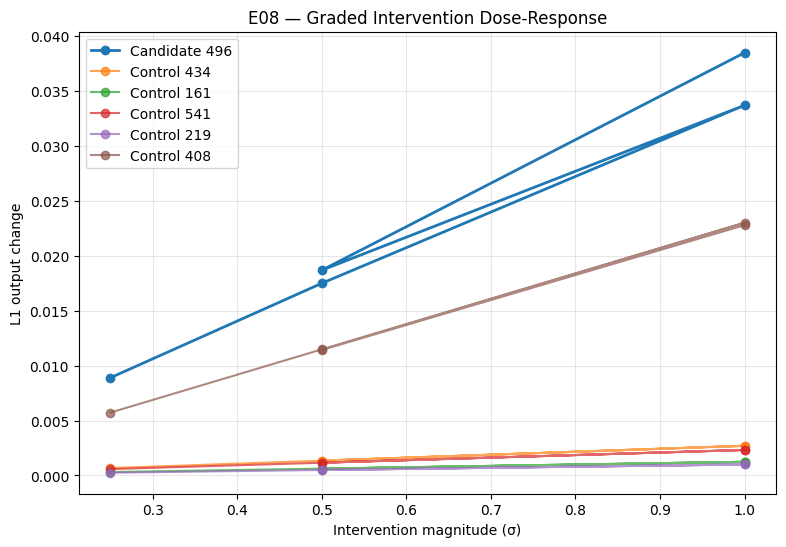

In [60]:
# ============================================================
# E08 — Dose-Response Grafiği
# Amaç: Müdahale büyüklüğü arttıkça aday ve kontrol
# boyutlarının L1 çıktı değişimini görsel olarak karşılaştırmak.
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# Aday boyutun sonuçlarını çiz.
candidate_magnitudes_plot = [
    result["intervention_magnitude"]
    for result in candidate_results
]

candidate_l1_plot = [
    result["l1_change"]
    for result in candidate_results
]

plt.plot(
    candidate_magnitudes_plot,
    candidate_l1_plot,
    marker="o",
    linewidth=2,
    label=f"Candidate {CANDIDATE_DIMENSION}"
)

# Her kontrol boyutunu ayrı çiz.
for control_dimension in CONTROL_DIMENSIONS:

    dimension_results = [
        result
        for result in all_control_results
        if result["dimension"] == control_dimension
    ]

    magnitudes = [
        result["intervention_magnitude"]
        for result in dimension_results
    ]

    l1_values = [
        result["l1_change"]
        for result in dimension_results
    ]

    plt.plot(
        magnitudes,
        l1_values,
        marker="o",
        alpha=0.7,
        label=f"Control {control_dimension}"
    )

plt.xlabel("Intervention magnitude (σ)")
plt.ylabel("L1 output change")
plt.title("E08 — Graded Intervention Dose-Response")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

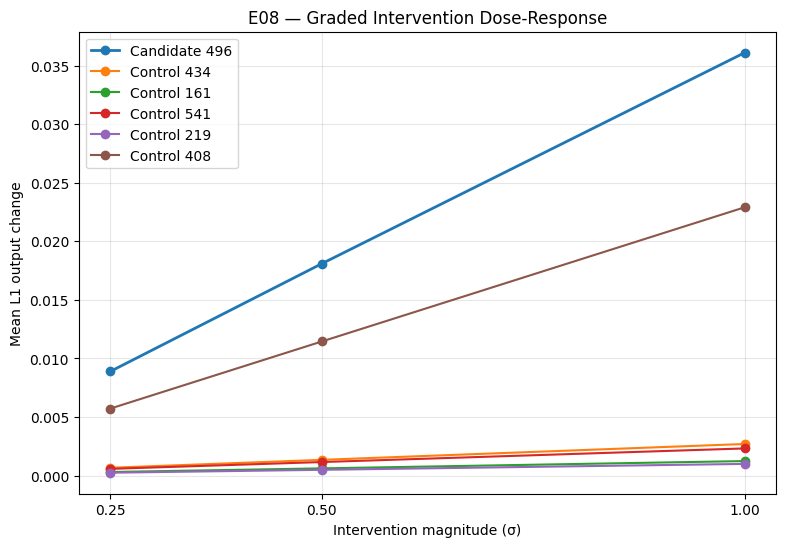

In [61]:
# ============================================================
# E08 — Düzeltilmiş Dose-Response Grafiği
# Amaç: Aynı müdahale büyüklüğündeki negatif ve pozitif
# müdahaleleri ortalayarak temiz bir dose-response grafiği üretmek.
# ============================================================

import matplotlib.pyplot as plt

# Kullanılacak müdahale büyüklükleri.
unique_magnitudes = sorted(
    set(intervention_magnitudes)
)

plt.figure(figsize=(9, 6))

# ------------------------------------------------------------
# Aday boyut
# ------------------------------------------------------------

candidate_plot_values = []

for magnitude in unique_magnitudes:

    matching_results = [
        result["l1_change"]
        for result in candidate_results
        if result["intervention_magnitude"] == magnitude
    ]

    candidate_plot_values.append(
        np.mean(matching_results)
    )

plt.plot(
    unique_magnitudes,
    candidate_plot_values,
    marker="o",
    linewidth=2,
    label=f"Candidate {CANDIDATE_DIMENSION}"
)


# ------------------------------------------------------------
# Kontrol boyutları
# ------------------------------------------------------------

for control_dimension in CONTROL_DIMENSIONS:

    dimension_results = [
        result
        for result in all_control_results
        if result["dimension"] == control_dimension
    ]

    control_plot_values = []

    for magnitude in unique_magnitudes:

        matching_results = [
            result["l1_change"]
            for result in dimension_results
            if result["intervention_magnitude"] == magnitude
        ]

        control_plot_values.append(
            np.mean(matching_results)
        )

    plt.plot(
        unique_magnitudes,
        control_plot_values,
        marker="o",
        linewidth=1.5,
        label=f"Control {control_dimension}"
    )


plt.xlabel("Intervention magnitude (σ)")
plt.ylabel("Mean L1 output change")
plt.title("E08 — Graded Intervention Dose-Response")
plt.xticks(unique_magnitudes)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

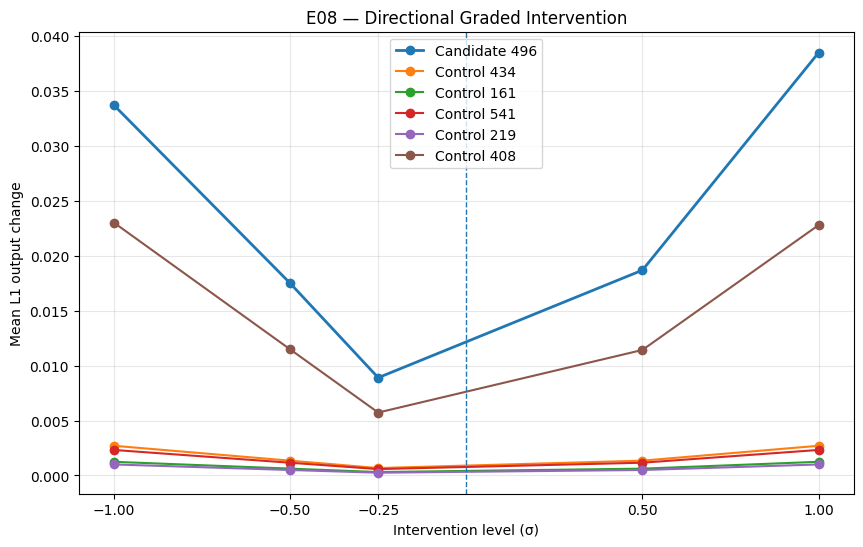

In [62]:
# ============================================================
# E08 — Yönlü Dose-Response Grafiği
# Amaç: Negatif ve pozitif müdahaleleri ayrı göstererek
# müdahalenin hem büyüklüğünü hem yönünü görselleştirmek.
# ============================================================

plt.figure(figsize=(10, 6))

# Müdahale seviyelerini küçükten büyüğe sırala.
sorted_levels = sorted(INTERVENTION_LEVELS)

# ------------------------------------------------------------
# Aday boyut
# ------------------------------------------------------------

candidate_directional_l1 = []

for level in sorted_levels:

    matching_results = [
        result["l1_change"]
        for result in candidate_results
        if result["intervention_level"] == level
    ]

    candidate_directional_l1.append(
        np.mean(matching_results)
    )

plt.plot(
    sorted_levels,
    candidate_directional_l1,
    marker="o",
    linewidth=2,
    label=f"Candidate {CANDIDATE_DIMENSION}"
)

# ------------------------------------------------------------
# Kontrol boyutları
# ------------------------------------------------------------

for control_dimension in CONTROL_DIMENSIONS:

    dimension_results = [
        result
        for result in all_control_results
        if result["dimension"] == control_dimension
    ]

    control_directional_l1 = []

    for level in sorted_levels:

        matching_results = [
            result["l1_change"]
            for result in dimension_results
            if result["intervention_level"] == level
        ]

        control_directional_l1.append(
            np.mean(matching_results)
        )

    plt.plot(
        sorted_levels,
        control_directional_l1,
        marker="o",
        linewidth=1.5,
        label=f"Control {control_dimension}"
    )

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Intervention level (σ)")
plt.ylabel("Mean L1 output change")
plt.title("E08 — Directional Graded Intervention")
plt.xticks(sorted_levels)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [64]:
# ============================================================
# E08 — Final Sonuç Tablosu
# Amaç: Aday ve kontrol boyutlarının temel E08 sonuçlarını
# tek tabloda toplamak ve karşılaştırmayı standartlaştırmak.
# ============================================================

import pandas as pd

final_results = []

# ------------------------------------------------------------
# Aday
# ------------------------------------------------------------

candidate_magnitudes_final = [
    result["intervention_magnitude"]
    for result in candidate_results
]

candidate_l1_values_final = [
    result["l1_change"]
    for result in candidate_results
]

candidate_spearman, candidate_spearman_p = spearmanr(
    candidate_magnitudes_final,
    candidate_l1_values_final
)

final_results.append({
    "type": "candidate",
    "dimension": CANDIDATE_DIMENSION,
    "mean_L1": candidate_mean_l1,
    "Spearman_rho": candidate_spearman,
    "Spearman_p": candidate_spearman_p,
    "percentile_vs_controls": candidate_percentile
})


# ------------------------------------------------------------
# Kontroller
# ------------------------------------------------------------

for control_dimension in CONTROL_DIMENSIONS:

    dimension_results = [
        result
        for result in all_control_results
        if result["dimension"] == control_dimension
    ]

    control_magnitudes = [
        result["intervention_magnitude"]
        for result in dimension_results
    ]

    control_l1_values = [
        result["l1_change"]
        for result in dimension_results
    ]

    control_spearman, control_spearman_p = spearmanr(
        control_magnitudes,
        control_l1_values
    )

    control_mean_l1 = np.mean(control_l1_values)

    final_results.append({
        "type": "control",
        "dimension": control_dimension,
        "mean_L1": control_mean_l1,
        "Spearman_rho": control_spearman,
        "Spearman_p": control_spearman_p,
        "percentile_vs_controls": np.nan
    })


# ------------------------------------------------------------
# Tabloyu oluştur
# ------------------------------------------------------------

e08_final_table = pd.DataFrame(final_results)

e08_final_table = e08_final_table.sort_values(
    "mean_L1",
    ascending=False
).reset_index(drop=True)

print("E08 — Final Sonuç Tablosu")
print()

display(
    e08_final_table.round({
        "mean_L1": 6,
        "Spearman_rho": 4,
        "Spearman_p": 6,
        "percentile_vs_controls": 2
    })
)

E08 — Final Sonuç Tablosu



,type,dimension,mean_L1,Spearman_rho,Spearman_p,percentile_vs_controls
0,candidate,496,0.023454,0.9487,0.013847,100.0
1,control,408,0.014887,0.9487,0.013847,NaN
2,control,434,0.001757,0.9487,0.013847,NaN
3,control,541,0.001511,0.9487,0.013847,NaN
4,control,161,0.000810,0.9487,0.013847,NaN
5,control,219,0.000652,0.9487,0.013847,NaN


In [65]:
# ============================================================
# E08 — Başarı Kriterlerinin Değerlendirilmesi
# Amaç: E08 deneyinin önceden belirlenen kriterlerini
# ölçülen sonuçlarla açıkça karşılaştırmak.
# ============================================================

candidate_rho_abs = abs(candidate_spearman)

candidate_monotonicity_pass = candidate_rho_abs >= 0.80

control_rhos = e08_final_table.loc[
    e08_final_table["type"] == "control",
    "Spearman_rho"
].to_numpy()

control_specificity_pass = np.any(
    np.abs(control_rhos) < 0.50
)

candidate_vs_control_pass = (
    candidate_mean_l1 >
    np.max(control_effects)
)

print("E08 — Başarı Kriterleri")
print("=" * 60)

print(
    f"1. Aday |Spearman rho| >= 0.80: "
    f"{candidate_rho_abs:.4f} -> "
    f"{'PASS' if candidate_monotonicity_pass else 'FAIL'}"
)

print(
    f"2. Kontrollerden daha yüksek aday etkisi: "
    f"{candidate_mean_l1:.6f} > "
    f"{np.max(control_effects):.6f} -> "
    f"{'PASS' if candidate_vs_control_pass else 'FAIL'}"
)

print(
    f"3. En az bir kontrol |rho| < 0.50: "
    f"{'PASS' if control_specificity_pass else 'FAIL'}"
)

print()
print("Kontrol Spearman değerleri:")
print(np.round(control_rhos, 4))

print()
print("Genel değerlendirme:")

if candidate_monotonicity_pass and candidate_vs_control_pass:
    print("PARTIAL / SUPPORT")
    print(
        "Aday güçlü ve kontrollerden daha büyük bir "
        "dose-response etkisi göstermektedir."
    )
    print(
        "Ancak kontrol boyutlarında da benzer monotonluk "
        "görüldüğü için Spearman özgüllüğü desteklememektedir."
    )
else:
    print("FAIL")

E08 — Başarı Kriterleri
1. Aday |Spearman rho| >= 0.80: 0.9487 -> PASS
2. Kontrollerden daha yüksek aday etkisi: 0.023454 > 0.014887 -> PASS
3. En az bir kontrol |rho| < 0.50: FAIL

Kontrol Spearman değerleri:
[0.9487 0.9487 0.9487 0.9487 0.9487]

Genel değerlendirme:
PARTIAL / SUPPORT
Aday güçlü ve kontrollerden daha büyük bir dose-response etkisi göstermektedir.
Ancak kontrol boyutlarında da benzer monotonluk görüldüğü için Spearman özgüllüğü desteklememektedir.
